Original Columns:

Index(['date and time', 'Water temperature [°C]', 'Conductivitiy [µS/cm]',
       'Oxygen [mg/l]', 'Turbidity [FNU]', 'Suspended solids [mg/l]',
       'Ptot [µg/l]', 'DOC [mg/l]', 'TOC [mg/l]', 'Total chlorophyll a [µg/l]',
       'chlorophyll of Cyanobacteria (not calibrated) [µg/l]',
       'Velocity [cm/s]', 'Discharge [l/s]'],
      dtype='object')

Cleaned dataset shape: (32631, 4)

Turbidity Model Performance
------------------------------
R2 Score : 0.969
RMSE     : 1.951

Conductivity Model Performance
------------------------------
R2 Score : 0.886
RMSE     : 1.708


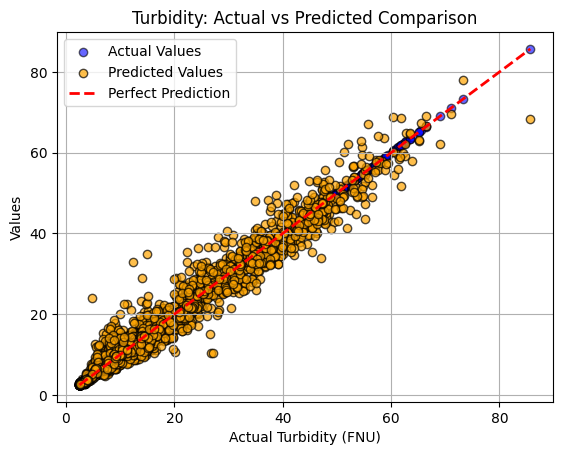

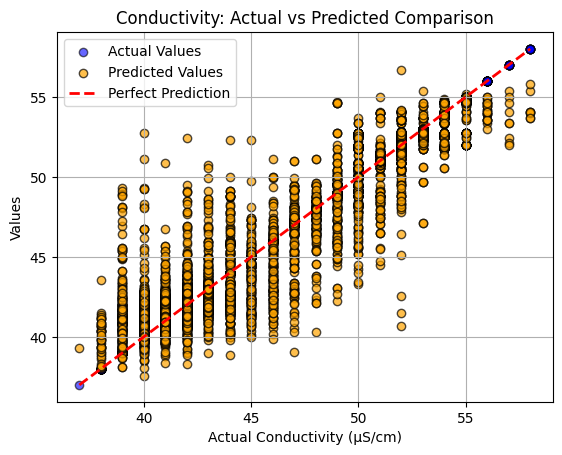

In [7]:

# Water Quality Prediction Model
# Predicting Turbidity & Conductivity



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. LOAD DATA 


df = pd.read_csv("luke_data.csv", sep=";")

print("Original Columns:\n")
print(df.columns)


# 2. FIX DECIMALS


for col in df.columns:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False)

# 3. RENAME COLUMNS 


df = df.rename(columns={
    "Ptot [µg/l]": "phosphorus",
    "Oxygen [mg/l]": "oxygen",
    "Turbidity [FNU]": "turbidity",
    "Conductivitiy [µS/cm]": "conductivity"
})


# 4. CONVERT TO NUMERIC 

cols = ["phosphorus", "oxygen", "turbidity", "conductivity"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[cols].dropna()

print("\nCleaned dataset shape:", df.shape)

# 5. FEATURES & TARGETS


X = df[["phosphorus", "oxygen"]]

y_turbidity = df["turbidity"]
y_conductivity = df["conductivity"]


# 6. TRAIN-TEST SPLIT

X_train, X_test, y_turb_train, y_turb_test = train_test_split(
    X, y_turbidity, test_size=0.2, random_state=42
)

_, _, y_cond_train, y_cond_test = train_test_split(
    X, y_conductivity, test_size=0.2, random_state=42
)


# 7. TRAIN MODELS


model_turbidity = RandomForestRegressor(n_estimators=100, random_state=42)
model_conductivity = RandomForestRegressor(n_estimators=100, random_state=42)

model_turbidity.fit(X_train, y_turb_train)
model_conductivity.fit(X_train, y_cond_train)


# 8. PREDICTIONS


y_turb_pred = model_turbidity.predict(X_test)
y_cond_pred = model_conductivity.predict(X_test)

# 9. EVALUATION FUNCTION


def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name} Model Performance")
    print("-" * 30)
    print(f"R2 Score : {r2:.3f}")
    print(f"RMSE     : {rmse:.3f}")

evaluate(y_turb_test, y_turb_pred, "Turbidity")
evaluate(y_cond_test, y_cond_pred, "Conductivity")


# 10. PLOTS


plt.figure()

# Actual values
plt.scatter(
    y_turb_test,
    y_turb_test,
    color="blue",
    alpha=0.6,
    label="Actual Values",
    edgecolors="black"
)

# Predicted values
plt.scatter(
    y_turb_test,
    y_turb_pred,
    color="orange",
    alpha=0.7,
    label="Predicted Values",
    edgecolors="black"
)

# Perfect prediction line
plt.plot(
    [y_turb_test.min(), y_turb_test.max()],
    [y_turb_test.min(), y_turb_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Turbidity (FNU)")
plt.ylabel("Values")
plt.title("Turbidity: Actual vs Predicted Comparison")
plt.legend()
plt.grid(True)
plt.show()





plt.figure()

# Actual values
plt.scatter(
    y_cond_test,
    y_cond_test,
    color="blue",
    alpha=0.6,
    label="Actual Values",
    edgecolors="black"
)

# Predicted values
plt.scatter(
    y_cond_test,
    y_cond_pred,
    color="orange",
    alpha=0.7,
    label="Predicted Values",
    edgecolors="black"
)

# Perfect prediction line
plt.plot(
    [y_cond_test.min(), y_cond_test.max()],
    [y_cond_test.min(), y_cond_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Conductivity (µS/cm)")
plt.ylabel("Values")
plt.title("Conductivity: Actual vs Predicted Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
print(df.columns)

Index(['date and time;Water temperature [°C];Conductivitiy [µS/cm];Oxygen [mg/l];Turbidity [FNU];Suspended solids [mg/l];Ptot [µg/l];DOC [mg/l];TOC [mg/l];Total chlorophyll a [µg/l];chlorophyll of Cyanobacteria (not calibrated) [µg/l];Velocity [cm/s];Discharge [l/s]'], dtype='object')


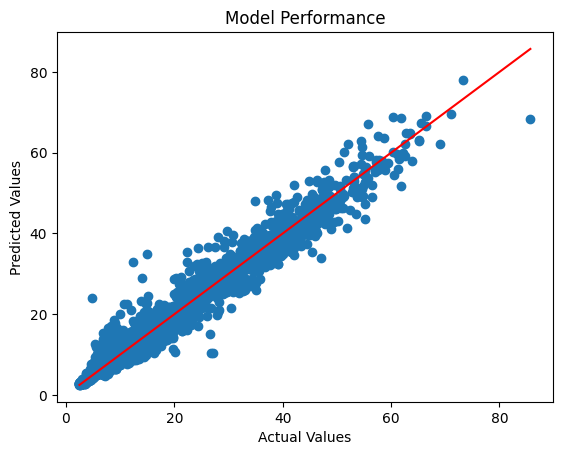

In [8]:
plt.scatter(y_turb_test, y_turb_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Model Performance")
plt.plot([min(y_turb_test), max(y_turb_test)],
         [min(y_turb_test), max(y_turb_test)],
         color='red')
plt.show()

Original Columns:

Index(['date and time', 'Water temperature [°C]', 'Conductivitiy [µS/cm]',
       'Oxygen [mg/l]', 'Turbidity [FNU]', 'Suspended solids [mg/l]',
       'Ptot [µg/l]', 'DOC [mg/l]', 'TOC [mg/l]', 'Total chlorophyll a [µg/l]',
       'chlorophyll of Cyanobacteria (not calibrated) [µg/l]',
       'Velocity [cm/s]', 'Discharge [l/s]'],
      dtype='object')

Cleaned dataset shape: (32631, 16)


/var/folders/tz/zm2hlwcj0tlbxc09z_25rgl00000gn/T/ipykernel_2681/1849987991.py:35: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date and time"] = pd.to_datetime(df["date and time"], errors="coerce")



Turbidity Model Performance
------------------------------
R2 Score : 0.992
RMSE     : 0.977

Conductivity Model Performance
------------------------------
R2 Score : 0.993
RMSE     : 0.411

Sample Predictions with Time:

                  Time  Actual_Turbidity  Predicted_Turbidity
6  2019-10-24 16:30:00              16.4            15.776367
8  2019-10-24 17:30:00              19.0            18.041000
23 2019-10-25 01:00:00              15.3            15.548250
30 2019-10-25 04:30:00              16.3            15.552167
33 2019-10-25 06:00:00              15.2            15.198750
34 2019-10-25 06:30:00              15.1            15.198750
35 2019-10-25 07:00:00              15.8            15.601000
43 2019-10-25 11:00:00              16.8            15.698667
46 2019-10-25 12:30:00              15.9            16.103417
52 2019-10-25 15:30:00              17.1            15.473500


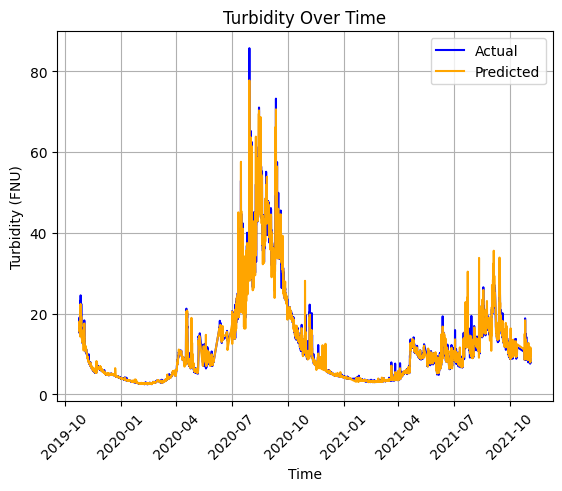

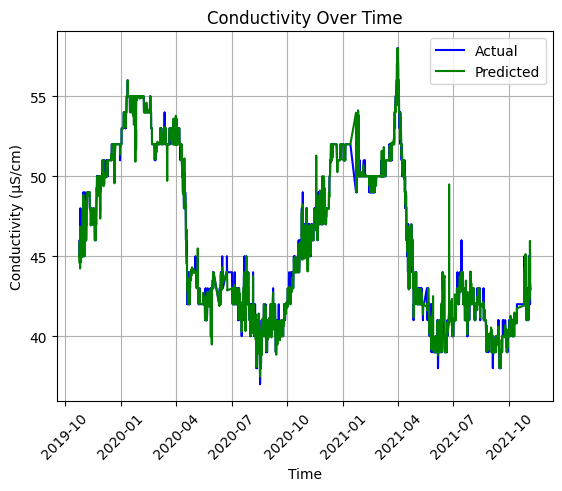

In [10]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error




df = pd.read_csv("luke_data.csv", sep=";")

print("Original Columns:\n")
print(df.columns)



for col in df.columns:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False)



df["date and time"] = pd.to_datetime(df["date and time"], errors="coerce")

df["hour"] = df["date and time"].dt.hour
df["day"] = df["date and time"].dt.day
df["month"] = df["date and time"].dt.month


df = df.rename(columns={
    "Ptot [µg/l]": "phosphorus",
    "Oxygen [mg/l]": "oxygen",
    "Turbidity [FNU]": "turbidity",
    "Conductivitiy [µS/cm]": "conductivity"
})



cols = ["phosphorus", "oxygen", "turbidity", "conductivity", "hour", "day", "month"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

print("\nCleaned dataset shape:", df.shape)



X = df[["phosphorus", "oxygen", "hour", "day", "month"]]

y_turbidity = df["turbidity"]
y_conductivity = df["conductivity"]



X_train, X_test, y_turb_train, y_turb_test = train_test_split(
    X, y_turbidity, test_size=0.2, random_state=42
)

_, _, y_cond_train, y_cond_test = train_test_split(
    X, y_conductivity, test_size=0.2, random_state=42
)



model_turbidity = RandomForestRegressor(n_estimators=100, random_state=42)
model_conductivity = RandomForestRegressor(n_estimators=100, random_state=42)

model_turbidity.fit(X_train, y_turb_train)
model_conductivity.fit(X_train, y_cond_train)



y_turb_pred = model_turbidity.predict(X_test)
y_cond_pred = model_conductivity.predict(X_test)



def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name} Model Performance")
    print("-" * 30)
    print(f"R2 Score : {r2:.3f}")
    print(f"RMSE     : {rmse:.3f}")

evaluate(y_turb_test, y_turb_pred, "Turbidity")
evaluate(y_cond_test, y_cond_pred, "Conductivity")



results = X_test.copy()
results["Time"] = df.loc[X_test.index, "date and time"]

results["Actual_Turbidity"] = y_turb_test.values
results["Predicted_Turbidity"] = y_turb_pred

results["Actual_Conductivity"] = y_cond_test.values
results["Predicted_Conductivity"] = y_cond_pred

results = results.sort_values("Time")

print("\nSample Predictions with Time:\n")
print(results[["Time", "Actual_Turbidity", "Predicted_Turbidity"]].head(10))



# TURBIDITY OVER TIME
plt.figure()

plt.plot(results["Time"], results["Actual_Turbidity"],
         label="Actual", color="blue")

plt.plot(results["Time"], results["Predicted_Turbidity"],
         label="Predicted", color="orange")

plt.xlabel("Time")
plt.ylabel("Turbidity (FNU)")
plt.title("Turbidity Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# CONDUCTIVITY OVER TIME
plt.figure()

plt.plot(results["Time"], results["Actual_Conductivity"],
         label="Actual", color="blue")

plt.plot(results["Time"], results["Predicted_Conductivity"],
         label="Predicted", color="green")

plt.xlabel("Time")
plt.ylabel("Conductivity (µS/cm)")
plt.title("Conductivity Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Original Columns:

Index(['date and time', 'Water temperature [°C]', 'Conductivitiy [µS/cm]',
       'Oxygen [mg/l]', 'Turbidity [FNU]', 'Suspended solids [mg/l]',
       'Ptot [µg/l]', 'DOC [mg/l]', 'TOC [mg/l]', 'Total chlorophyll a [µg/l]',
       'chlorophyll of Cyanobacteria (not calibrated) [µg/l]',
       'Velocity [cm/s]', 'Discharge [l/s]'],
      dtype='object')

Cleaned dataset shape: (32631, 16)


/var/folders/tz/zm2hlwcj0tlbxc09z_25rgl00000gn/T/ipykernel_2681/458952495.py:35: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date and time"] = pd.to_datetime(df["date and time"], errors="coerce")



Turbidity Model Performance
------------------------------
R2 Score : 0.992
RMSE     : 0.977

Conductivity Model Performance
------------------------------
R2 Score : 0.993
RMSE     : 0.411

🌊 TURBIDITY PREDICTIONS:

                  Time  Actual_Turbidity  Predicted_Turbidity
6  2019-10-24 16:30:00              16.4            15.776367
8  2019-10-24 17:30:00              19.0            18.041000
23 2019-10-25 01:00:00              15.3            15.548250
30 2019-10-25 04:30:00              16.3            15.552167
33 2019-10-25 06:00:00              15.2            15.198750
34 2019-10-25 06:30:00              15.1            15.198750
35 2019-10-25 07:00:00              15.8            15.601000
43 2019-10-25 11:00:00              16.8            15.698667
46 2019-10-25 12:30:00              15.9            16.103417
52 2019-10-25 15:30:00              17.1            15.473500

⚡ CONDUCTIVITY PREDICTIONS:

                  Time  Actual_Conductivity  Predicted_Conductivity
6 

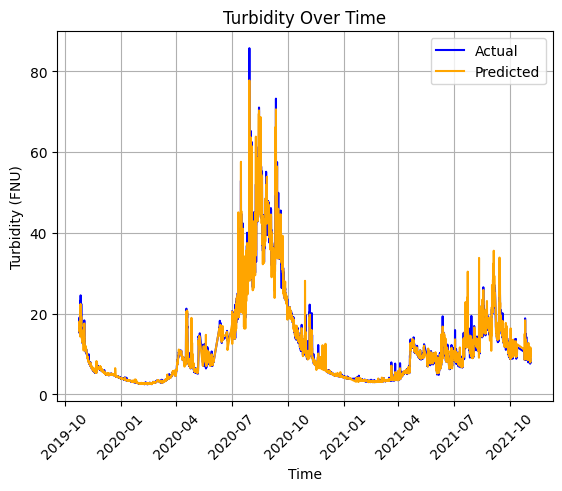

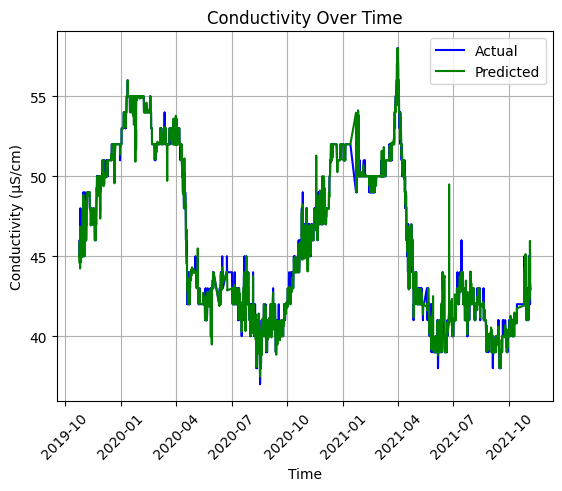

In [11]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


# 1. LOAD DATA

df = pd.read_csv("luke_data.csv", sep=";")

print("Original Columns:\n")
print(df.columns)

# 2. FIX DECIMALS 

for col in df.columns:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False)


# 3. TIME FEATURE ENGINEERING


df["date and time"] = pd.to_datetime(df["date and time"], errors="coerce")

df["hour"] = df["date and time"].dt.hour
df["day"] = df["date and time"].dt.day
df["month"] = df["date and time"].dt.month


# 4. RENAME COLUMNS


df = df.rename(columns={
    "Ptot [µg/l]": "phosphorus",
    "Oxygen [mg/l]": "oxygen",
    "Turbidity [FNU]": "turbidity",
    "Conductivitiy [µS/cm]": "conductivity"
})


# 5. CLEAN DATA


cols = ["phosphorus", "oxygen", "turbidity", "conductivity", "hour", "day", "month"]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

print("\nCleaned dataset shape:", df.shape)

# 6. FEATURES & TARGETS


X = df[["phosphorus", "oxygen", "hour", "day", "month"]]

y_turbidity = df["turbidity"]
y_conductivity = df["conductivity"]

# 7. TRAIN-TEST SPLIT

X_train, X_test, y_turb_train, y_turb_test = train_test_split(
    X, y_turbidity, test_size=0.2, random_state=42
)

_, _, y_cond_train, y_cond_test = train_test_split(
    X, y_conductivity, test_size=0.2, random_state=42
)


# 8. TRAIN MODELS


model_turbidity = RandomForestRegressor(n_estimators=100, random_state=42)
model_conductivity = RandomForestRegressor(n_estimators=100, random_state=42)

model_turbidity.fit(X_train, y_turb_train)
model_conductivity.fit(X_train, y_cond_train)


# 9. PREDICTIONS


y_turb_pred = model_turbidity.predict(X_test)
y_cond_pred = model_conductivity.predict(X_test)


# 10. EVALUATION


def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n{name} Model Performance")
    print("-" * 30)
    print(f"R2 Score : {r2:.3f}")
    print(f"RMSE     : {rmse:.3f}")

evaluate(y_turb_test, y_turb_pred, "Turbidity")
evaluate(y_cond_test, y_cond_pred, "Conductivity")


# 11. TIME-AWARE RESULTS TABLE


results = X_test.copy()

results["Time"] = df.loc[X_test.index, "date and time"]

# Turbidity
results["Actual_Turbidity"] = y_turb_test.values
results["Predicted_Turbidity"] = y_turb_pred

# Conductivity
results["Actual_Conductivity"] = y_cond_test.values
results["Predicted_Conductivity"] = y_cond_pred

results = results.sort_values("Time")

print("\n🌊 TURBIDITY PREDICTIONS:\n")
print(results[["Time", "Actual_Turbidity", "Predicted_Turbidity"]].head(10))

print("\n⚡ CONDUCTIVITY PREDICTIONS:\n")
print(results[["Time", "Actual_Conductivity", "Predicted_Conductivity"]].head(10))


# 12. TIME SERIES VISUALIZATION


# TURBIDITY OVER TIME
plt.figure()

plt.plot(results["Time"], results["Actual_Turbidity"],
         label="Actual", color="blue")

plt.plot(results["Time"], results["Predicted_Turbidity"],
         label="Predicted", color="orange")

plt.xlabel("Time")
plt.ylabel("Turbidity (FNU)")
plt.title("Turbidity Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# CONDUCTIVITY OVER TIME
plt.figure()

plt.plot(results["Time"], results["Actual_Conductivity"],
         label="Actual", color="blue")

plt.plot(results["Time"], results["Predicted_Conductivity"],
         label="Predicted", color="green")

plt.xlabel("Time")
plt.ylabel("Conductivity (µS/cm)")
plt.title("Conductivity Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [14]:



cond_results = X_test.copy()

cond_results["Time"] = df.loc[X_test.index, "date and time"]

cond_results["Actual_Conductivity"] = y_cond_test.values
cond_results["Predicted_Conductivity"] = y_cond_pred

cond_results = cond_results.sort_values("Time")

print("\n CONDUCTIVITY PREDICTIONS:\n")
print(cond_results[["Time", "Actual_Conductivity", "Predicted_Conductivity"]].head(10))


 CONDUCTIVITY PREDICTIONS:

                  Time  Actual_Conductivity  Predicted_Conductivity
6  2019-10-24 16:30:00                 45.0                  44.615
8  2019-10-24 17:30:00                 45.0                  45.000
23 2019-10-25 01:00:00                 45.0                  44.980
30 2019-10-25 04:30:00                 46.0                  45.720
33 2019-10-25 06:00:00                 45.0                  45.910
34 2019-10-25 06:30:00                 45.0                  45.910
35 2019-10-25 07:00:00                 45.0                  45.860
43 2019-10-25 11:00:00                 45.0                  45.140
46 2019-10-25 12:30:00                 45.0                  44.980
52 2019-10-25 15:30:00                 45.0                  45.020
